In [2]:
import numpy as np
from matplotlib import pyplot as plt
from keras.datasets import mnist
from collections import Counter

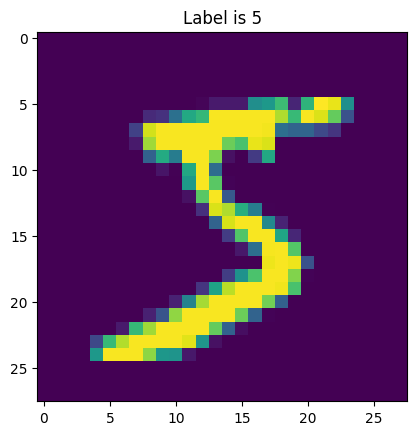

In [3]:
(Xtr, Ltr), (X_test, L_test) = mnist.load_data()

Image = Xtr[0,:,:]
Label = Ltr[0]

plt.title('Label is {Label}'.format(Label=Label))
plt.imshow(Image)

plt.show()
plt.close()


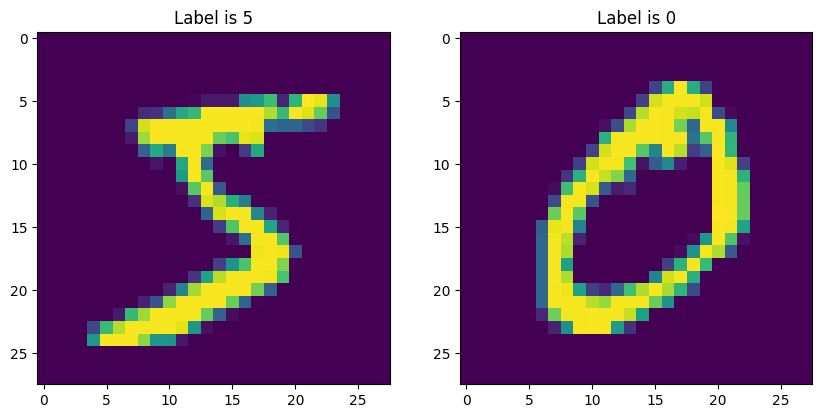

In [4]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 10))
ax0 = plt.subplot(1, 2, 1)
ax1 = plt.subplot(1, 2, 2)

Image = Xtr[0,:,:]
Label = Ltr[0]
Image1 = Xtr[1,:,:]
Label1 = Ltr[1]

ax0.set_title(f'Label is {Label}')
ax0.imshow(Image)
ax1.set_title(f'Label is {Label1}')
ax1.imshow(Image1)

plt.show()
plt.close()


In [7]:
# Preprocessing functions

def center(X):
    newX = X - np.mean(X, axis = 0)
    return newX

def standardise(X):
    with np.errstate(invalid='ignore'):
        newX = center(X)/np.std(X, axis = 0)
    return newX

def whiten(X):
    XCentered = center(X)
    cov = XCentered.T.dot(XCentered) / float(XCentered.shape[0])
    eigVals, eigVecs = np.linalg.eig(cov)
    decorrelated = X.dot(eigVecs)
    whitened = decorrelated / np.sqrt(eigVals + 1e-5)
    return whitened

def zca(X): 
    X = X.reshape(X.shape[0], X.shape[1] * X.shape[2])
    X_norm = X / 255.
    X_norm = X_norm - X_norm.mean(axis=0)
    cov = np.cov(X_norm, rowvar=False)
    U, S, V = np.linalg.svd(cov)
    epsilon = 0.1
    X_ZCA = U.dot(np.diag(1.0 / np.sqrt(S + epsilon))).dot(U.T).dot(X_norm.T).T
    X_ZCA_rescaled = (X_ZCA - X_ZCA.min()) / (X_ZCA.max() - X_ZCA.min())
    return X_ZCA_rescaled
    

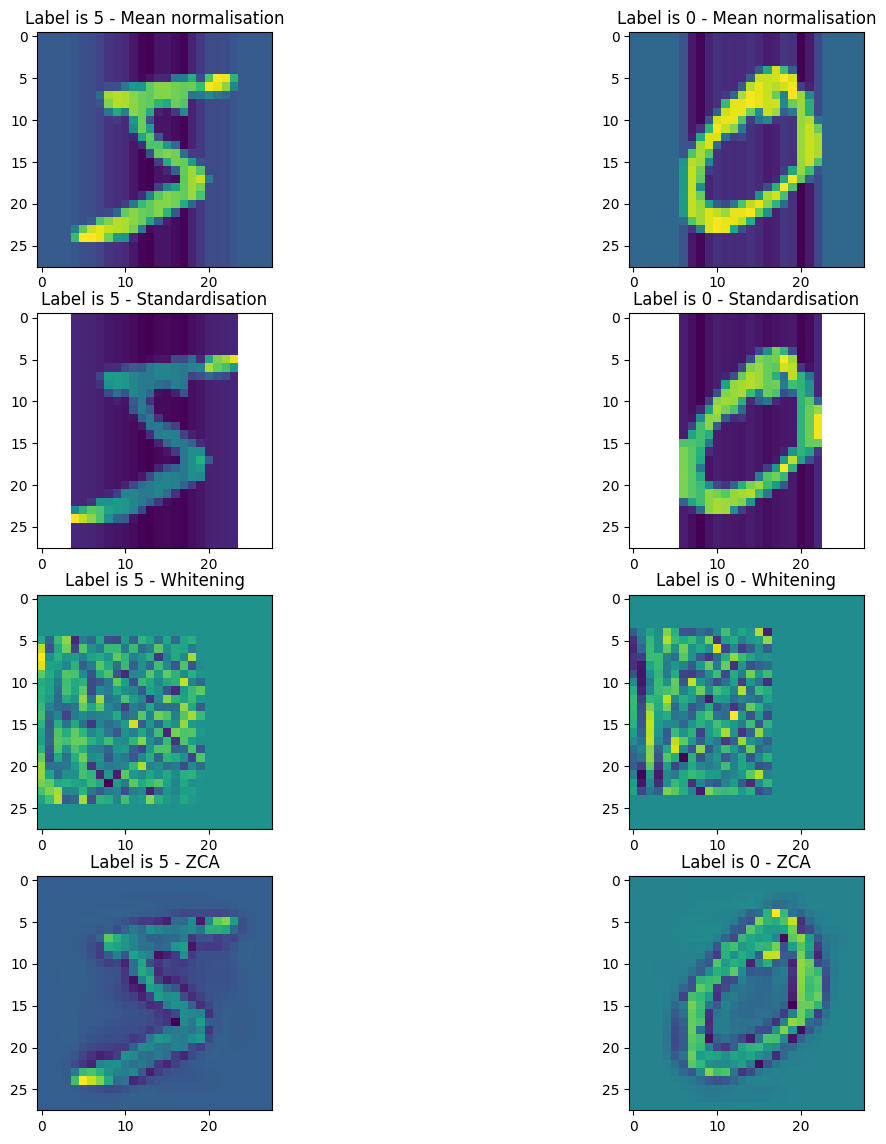

In [14]:
# Examples for visualisation - Mean normalisation, Standardisation and Whitening

fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(14, 14))
ax0 = plt.subplot(4, 2, 1)
ax1 = plt.subplot(4, 2, 2)
ax2 = plt.subplot(4, 2, 3)
ax3 = plt.subplot(4, 2, 4)
ax4 = plt.subplot(4, 2, 5)
ax5 = plt.subplot(4, 2, 6)
ax6 = plt.subplot(4, 2, 7)
ax7 = plt.subplot(4, 2, 8)

Image = Xtr[0,:,:]
Label = Ltr[0]
Image1 = Xtr[1,:,:]
Label1 = Ltr[1]

ax0.set_title(f'Label is {Label} - Mean normalisation')
ax0.imshow(center(Image))

ax1.set_title(f'Label is {Label1} - Mean normalisation')
ax1.imshow(center(Image1))

ax2.set_title(f'Label is {Label} - Standardisation')
ax2.imshow(standardise(Image))

ax3.set_title(f'Label is {Label1} - Standardisation')
ax3.imshow(standardise(Image1))

ax4.set_title(f'Label is {Label} - Whitening')
ax4.imshow(whiten(Image))

ax5.set_title(f'Label is {Label1} - Whitening')
ax5.imshow(whiten(Image1))

t_set = Xtr
t_set = zca(t_set) 

ax6.set_title(f'Label is {Label} - ZCA')
ax6.imshow(t_set[0,:].reshape(28, 28))

ax7.set_title(f'Label is {Label1} - ZCA')
ax7.imshow(t_set[1,:].reshape(28, 28))


plt.show()
plt.close()


In [15]:
# Training phase
num_sample = 1000
Tr_set = Xtr[:num_sample,:,:]
Ltr_set = Ltr[:num_sample]

#Tr_set = Tr_set.reshape(num_sample, Tr_set.shape[1] * Tr_set.shape[2])
Tr_set = Tr_set.reshape(num_sample, Tr_set.shape[1] * Tr_set.shape[2]).astype('float64')
#Tr_set = Tr_set / 255.0
print(Tr_set.dtype)

Tr_set.shape

float64


(1000, 784)

In [16]:
# Testing data

#Test_images = X_test.reshape(X_test.shape[0], X_test.shape[1] * X_test.shape[2])
Test_images = X_test.reshape(X_test.shape[0], X_test.shape[1] * X_test.shape[2]).astype('float64')
#Test_images = Test_images / 255.0
print(Test_images.dtype)



float64


In [17]:

def predict(test_data, training_data, label_training, L=1):
    num_test = test_data.shape[0]
    l_pred = np.zeros(num_test, dtype=label_training.dtype)

    for i in range(num_test):
        if L == 1: 
            distances = np.sum(np.abs(training_data - test_data[i,:]), axis=1)
        elif L == 2:    
            distances = np.sqrt(np.sum((training_data - test_data[i,:]) ** 2, axis=1))

        min_index = np.argmin(distances)
        l_pred[i] = label_training[min_index]

        
    return l_pred

In [220]:

labels_predicted = predict(Test_images, Tr_set, Ltr_set, L=2)

accuracy = np.mean(labels_predicted == L_test)
print(f"Accuracy: {accuracy} ; {accuracy * 100}%")


Accuracy: 0.869 ; 86.9%


In [18]:
def predict_knn(test_data, training_data, label_training, k, L=1):
    num_test = test_data.shape[0]
    l_pred = np.zeros(num_test, dtype=label_training.dtype)

    for i in range(num_test):
        distances = []
        for j in range(len(training_data)):        
            if L == 1: 
                dist = np.sum(np.abs(training_data[j] - test_data[i]))
            elif L == 2:    
                dist = np.sqrt(np.sum((training_data[j] - test_data[i]) ** 2))
            distances.append((dist, label_training[j]))

        distances.sort(key=lambda a: a[0])

        k_nearest = [label for _, label in distances[:k]]
        l_pred[i] = Counter(k_nearest).most_common(1)[0][0]
    return l_pred




In [19]:
k = 10
labels_predicted_k = predict_knn(Test_images, Tr_set, Ltr_set, k, L=2)

accuracy_knn = np.mean(labels_predicted_k == L_test)
print(f"Accuracy k-NN: {accuracy_knn} ; {accuracy_knn * 100}%")


Accuracy k-NN: 0.8544 ; 85.44%


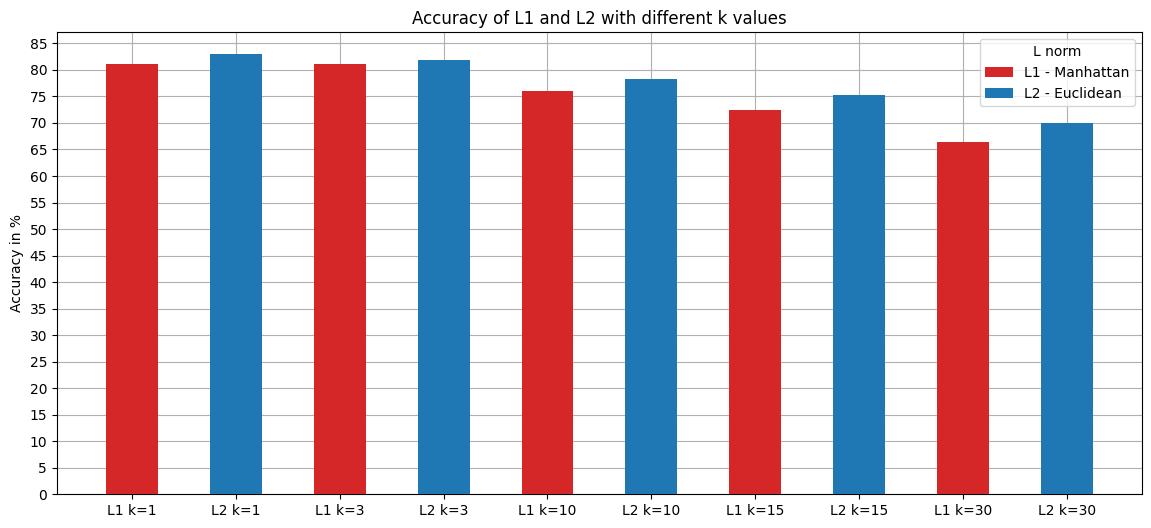

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

label = np.array(["L1 k=1", "L2 k=1", "L1 k=3", "L2 k=3", "L1 k=10", "L2 k=10", "L1 k=15", "L2 k=15", "L1 k=30", "L2 k=30"])
data = np.array([81.1, 82.94, 81.1, 81.89, 75.96, 78.28, 72.49, 75.22, 66.39, 69.91])
bar_labels = ['L1 - Manhattan', 'L2 - Euclidean', '', '', '', '','','','','']
bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:blue', 'tab:red', 'tab:blue', 'tab:red', 'tab:blue', 'tab:red', 'tab:blue']
ax.yaxis.set_ticks(np.arange(0, 100, 5))
ax.grid()

ax.bar(label, data, label=bar_labels, color=bar_colors, width=0.5, align='center', zorder=3)

ax.set_ylabel('Accuracy in %')
ax.set_title('Accuracy of L1 and L2 with different k values')
ax.legend(title='L norm')

plt.show()

In [106]:
# Before Hint: Accuracy: 0.811
# Without any changed: Accuracy: 0.2649
# Manhattan:  0.2649
# Euclidean: 0.19
# After bug: 81.1 manhattan
# after bug: 82.94 euclidean
